In [44]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [45]:
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 2)
    & (tourney_df['Illinois'] > 2)
    & (tourney_df['Duke'] > 2)
    & (tourney_df['Michigan'] > 2)
    & (tourney_df['Connecticut'] > 2)
    & (tourney_df['Tennessee'] > 2)
    ]
tourney_df.Probability = tourney_df.Probability / tourney_df.Probability.sum()

In [46]:
win_df = tourney_df[['Winner', 'Probability']].groupby(['Winner']).sum()
win_df.sort_values(by='Probability', ascending=False, inplace=True)

win_df_nice = win_df.copy()
win_df_nice = win_df_nice.loc[win_df_nice['Probability'] > 0.05]
other = 1.0 - win_df_nice['Probability'].sum()
if other > 0.0001:
    win_df_nice.loc['Other'] = [other]

second_df = tourney_df[['Second', 'Probability']].groupby(['Second']).sum()
second_df.sort_values(by='Probability', ascending=False, inplace=True)

second_df_nice = second_df.copy()
second_df_nice = second_df_nice.loc[second_df_nice['Probability'] > 0.05]
other = 1.0 - second_df_nice['Probability'].sum()
if other > 0.0001:
    second_df_nice.loc['Other'] = [other]

third_df = tourney_df[['Third', 'Probability']].groupby(['Third']).sum()
third_df.sort_values(by='Probability', ascending=False, inplace=True)

third_df_nice = third_df.copy()
third_df_nice = third_df_nice.loc[third_df_nice['Probability'] > 0.05]
other = 1.0 - third_df_nice['Probability'].sum()
if other > 0.0001:
    third_df_nice.loc['Other'] = [other]


In [47]:
all_labels = set(win_df_nice.index) | set(second_df_nice.index) | set(third_df_nice.index)

In [48]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [49]:
from math import sin, cos, sqrt, gcd, pi

seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

Dan Wros
George Wright
Justin Calvillo
Keith Schneider
Koy Kubasta
Mark Hurst
Nathan Sanches
Other
Patrick Commers
Serigne Diaw
Tyler Krause
none


{'Justin Calvillo': [0.5690355937288492,
  0.9633731610262555,
  0.6746980264314426],
 'Tyler Krause': [0.5080313597647761, 0.9023689270621824, 0.7967064943595888],
 'Patrick Commers': [0.5080313597647761,
  0.796706494359589,
  0.9023689270621824],
 'Other': [0.5690355937288492, 0.6746980264314427, 0.9633731610262555],
 'none': [0.6746980264314426, 0.5690355937288492, 0.9633731610262555],
 'George Wright': [0.7967064943595888, 0.5080313597647761, 0.9023689270621824],
 'Koy Kubasta': [0.9023689270621824, 0.5080313597647761, 0.796706494359589],
 'Mark Hurst': [0.9633731610262555, 0.569035593728849, 0.6746980264314428],
 'Nathan Sanches': [0.9633731610262556,
  0.6746980264314426,
  0.5690355937288493],
 'Serigne Diaw': [0.9023689270621824, 0.7967064943595888, 0.5080313597647761],
 'Dan Wros': [0.7967064943595891, 0.9023689270621823, 0.508031359764776],
 'Keith Schneider': [0.6746980264314428,
  0.9633731610262555,
  0.569035593728849]}

In [50]:
dfs = [win_df_nice, second_df_nice, third_df_nice]
disp_titles = ['1st Place', '2nd Place', '3rd Place']

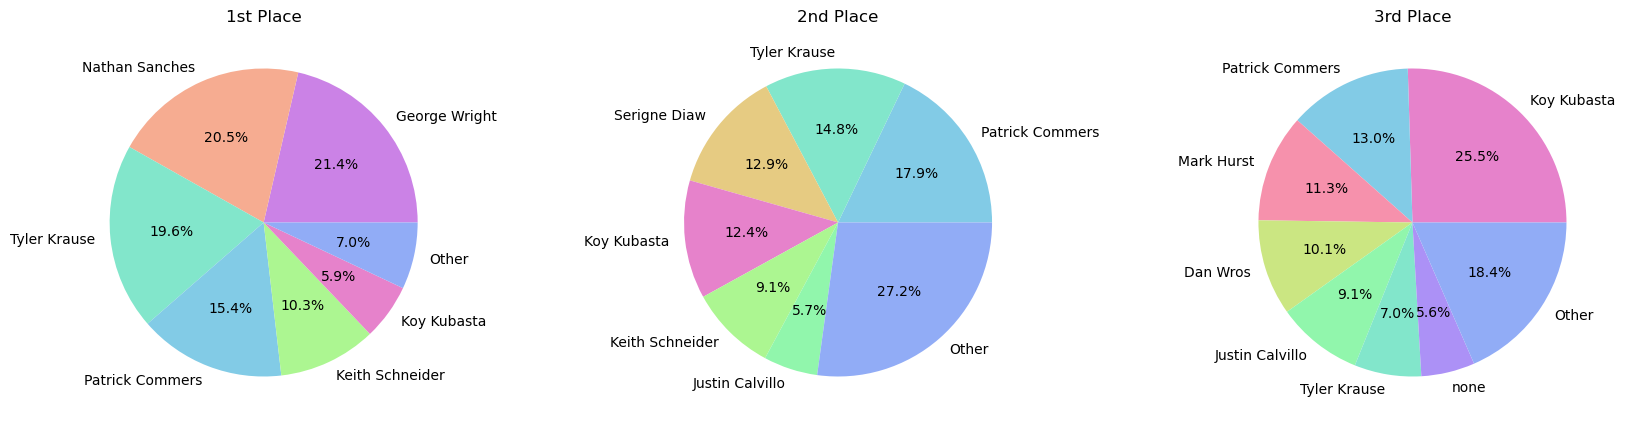

In [51]:
fig, axs = plt.subplots(1, 3, figsize = [21, 5])

for ax, title, df in zip(axs.flatten(), disp_titles, dfs):
    labels=df.index
    colors = [color_dict[label] for label in labels]
    labels = [_ for _ in labels]
    ax.pie(df['Probability'], 
           labels=labels,
           autopct='%1.1f%%',
           normalize=True,
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')

plt.savefig('plots/win_place_show_friday.png', dpi=300, bbox_inches='tight')

In [52]:
pot = 425.0
prizes = {
    1: 0.6 * pot,
    2: 0.3 * pot,
    3: .01 * pot
}

ev_dict = {}

for winner in win_df.index:
    winners = winner.split(', ')
    prob = win_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[1]
    elif nwinners == 2:
        total_prize = prizes[1] + prizes[2]
    else:
        total_prize = prizes[1] + prizes[2] + prizes[3]
    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in second_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = second_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[2]
    else:
        total_prize = prizes[2] + prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in third_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = third_df.loc[winner, 'Probability']
    nwinners = len(winners)
    total_prize = prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 
# ev_dict

ev_df = pd.DataFrame.from_dict(data=ev_dict, orient='index', columns=['EV (USD)'])
ev_df.sort_values(by='EV (USD)', ascending=False, inplace=True)
ev_df['EV (GBP)'] = ev_df['EV (USD)']  * 0.75
ev_df
    

,EV (USD),EV (GBP)
Tyler Krause,77.421451,58.066088
Patrick Commers,62.665587,46.999190
George Wright,61.056495,45.792371
Nathan Sanches,57.064998,42.798748
Keith Schneider,47.804481,35.853361
Koy Kubasta,31.886067,23.914551
Mark Hurst,16.573606,12.430204
Serigne Diaw,16.553776,12.415332
Justin Calvillo,7.637249,5.727937
Danny Ryan,4.046685,3.035014


In [53]:
from IPython.display import display

display(ev_df.style.format({
    'EV (USD)': '${:,.2f}',
    'EV (GBP)': '£{:,.2f}' # Example for a different currency without decimals
}))



,EV (USD),EV (GBP)
Tyler Krause,$77.42,£58.07
Patrick Commers,$62.67,£47.00
George Wright,$61.06,£45.79
Nathan Sanches,$57.06,£42.80
Keith Schneider,$47.80,£35.85
Koy Kubasta,$31.89,£23.91
Mark Hurst,$16.57,£12.43
Serigne Diaw,$16.55,£12.42
Justin Calvillo,$7.64,£5.73
Danny Ryan,$4.05,£3.04


In [54]:
print(ev_df)

                  EV (USD)   EV (GBP)
Tyler Krause     77.421451  58.066088
Patrick Commers  62.665587  46.999190
George Wright    61.056495  45.792371
Nathan Sanches   57.064998  42.798748
Keith Schneider  47.804481  35.853361
Koy Kubasta      31.886067  23.914551
Mark Hurst       16.573606  12.430204
Serigne Diaw     16.553776  12.415332
Justin Calvillo   7.637249   5.727937
Danny Ryan        4.046685   3.035014
Dan Wros          4.039605   3.029703


In [55]:
pd.set_option('display.max_colwidth', 70)
print(win_df)

                                           Probability
Winner                                                
George Wright                                 0.213884
Nathan Sanches                                0.204518
Tyler Krause                                  0.195762
Patrick Commers                               0.154172
Keith Schneider                               0.102921
Koy Kubasta                                   0.058676
Mark Hurst                                    0.030517
Keith Schneider, Tyler Krause                 0.026085
Keith Schneider, Mark Hurst                   0.008049
Keith Schneider, Mark Hurst, Tyler Krause     0.005415


In [56]:
pd.set_option('display.max_colwidth', 70)
print(second_df)

                                Probability
Second                                     
Patrick Commers                    0.178831
Tyler Krause                       0.148425
Serigne Diaw                       0.128677
Koy Kubasta                        0.124239
Keith Schneider                    0.091264
Justin Calvillo                    0.056881
Mark Hurst                         0.041944
George Wright                      0.041914
none                               0.039549
Nathan Sanches                     0.038533
Danny Ryan                         0.030517
Dan Wros                           0.028326
Keith Schneider, Tyler Krause      0.026832
George Wright, Tyler Krause        0.011350
Keith Schneider, Mark Hurst        0.009833
George Wright, Keith Schneider     0.001851
Mark Hurst, Tyler Krause           0.001033


In [57]:
pd.set_option('display.max_colwidth', 70)
print(third_df)

                                Probability
Third                                      
Koy Kubasta                        0.254869
Patrick Commers                    0.129564
Mark Hurst                         0.113287
Dan Wros                           0.100714
Justin Calvillo                    0.090566
Tyler Krause                       0.070200
none                               0.056314
George Wright                      0.048667
George Wright, Keith Schneider     0.044926
Danny Ryan                         0.036663
Serigne Diaw                       0.034694
Keith Schneider                    0.015145
Mark Hurst, Tyler Krause           0.004391
